In [1]:
import numpy as np
import pandas as pd   
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 데이터 로드
# -------------------------
df = pd.read_csv('univ355.csv')

# -------------------------
# 결측치 컬럼 제거
# -------------------------
drop_missing_cols = [
    'why_not_rechoice', 'future_job_desc', 'income_class', 'income_contest',
    'income_perf', 'income_broadcast', 'income_studio', 'income_creator',
    'income_choreo', 'info_dept', 'info_career_center', 'info_online',
    'info_family', 'info_friends', 'info_academy', 'info_self',
    'help_financial', 'help_resume', 'help_career', 'help_social',
    'help_no', 'non_stay_reason', 'total_univ'
]
df = df.drop(columns=drop_missing_cols, errors='ignore')

# -------------------------
# current_area 관련 변수 제거
# -------------------------
current_area_cols = [col for col in df.columns if col.startswith('current_area')]
df = df.drop(columns=current_area_cols, errors='ignore')

# -------------------------
# 오타 수정
# -------------------------
if 'birth_area' in df.columns:
    df['birth_area'] = df['birth_area'].replace({'g': 'gangwon'})  # 'g' -> 'gangwon'

# -------------------------
# 범주형 변수 매핑 및 원-핫 인코딩
# -------------------------
# dance_years 매핑
midpoint_map = {'less2':1, '2to4':2, '4to7':3, '7to10':4, 'over10':5}
if 'dance_years' in df.columns:
    df['dance_years'] = df['dance_years'].map(midpoint_map)

# 원-핫 인코딩
columns_to_encode = [
    'univ_factor', 'major_factor', 'job_region', 'weight_control',
    'birth_area', 'housing_type', 'enter_type',
    'major_detail', 'univ_name', 'univ_area'

]
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False, dtype=float)

# -------------------------
# 분석 제외 변수 제거
# -------------------------
remove_vars = ["prof_hi", "int_major", "enter_year"]
df = df.drop(columns=remove_vars, errors='ignore')

# -------------------------
# 상관계수 높은 변수 사전 삭제 (전처리 단계)
# -------------------------
high_corr_remove = ['lecture_qual', 'peer_personal', 'enjoy_major', 'prof_chat','peer_study']
df = df.drop(columns=high_corr_remove, errors='ignore')


# -------------------------
# sat 변수 생성 및 이진 분류
# -------------------------
sat_cols = ['univ_proud', 'univ_belong', 'major_proud', 'major_belong']
df['sat'] = df[sat_cols].mean(axis=1)
sat_median = df['sat'].median()
df['sat_group'] = (df['sat'] >= sat_median).astype(int)

# -------------------------
# 설명용 출력
# -------------------------
print("✅ 최종 데이터셋 컬럼 수:", df.shape[1])
print("sat 중위수:", sat_median)
print(df[['sat', 'sat_group']].head())



✅ 최종 데이터셋 컬럼 수: 178
sat 중위수: 4.0
    sat  sat_group
0  4.00          1
1  4.50          1
2  3.00          0
3  3.00          0
4  4.75          1


In [2]:
# ======================================
# ✅ 최적화 버전 (6:2:2 분할)
# ElasticNet + RFECV(LR/DT/RF/XGB)
# - 변수선택: X_train 내부에서 수행
# - 폴드별 선택 변수 → 교집합(안정적 변수)
# - CV, Validation, Test 평가 분리
# ======================================

import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 설정
# -------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 데이터 존재 확인
# -------------------------
try:
    df
except NameError:
    raise RuntimeError("데이터프레임 df가 존재하지 않습니다. 먼저 전처리 셀을 실행하세요.")

# -------------------------
# 타깃/설명변수 설정
# -------------------------
target_col = 'sat_group'
drop_cols = ['id','univ_proud','univ_belong','major_proud','major_belong','sat','sat_group']
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
y = df[target_col].copy()

# -------------------------
# 학습/검증/테스트 분할 (6:2:2)
# -------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# -------------------------
# CV 설정
# -------------------------
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

# -------------------------
# RFECV 파이프라인 생성 함수
# -------------------------
def make_rfecv_pipeline(base_estimator, final_estimator=None):
    """RFECV 기반 파이프라인 생성"""
    if final_estimator is None:
        final_estimator = base_estimator
    rfecv = RFECV(
        estimator=base_estimator,
        step=1,
        cv=inner_cv,
        scoring='f1',
        min_features_to_select=max(1, int(0.05 * X_train.shape[1])),
        n_jobs=1,
        verbose=0
    )
    # LogisticRegression일 때만 스케일러 추가
    if isinstance(base_estimator, LogisticRegression):
        return Pipeline([("scaler", StandardScaler()),
                         ("feature_selection", rfecv),
                         ("clf", final_estimator)])
    else:
        return Pipeline([("feature_selection", rfecv),
                         ("clf", final_estimator)])

# -------------------------
# 모델 정의
# -------------------------
models = {
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=10, cv=inner_cv, penalty="elasticnet", solver="saga",
            l1_ratios=[.1,.3,.5,.7,.9], scoring="f1",
            max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    "RFECV_LR": make_rfecv_pipeline(LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)),
    "RFECV_DT": make_rfecv_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "RFECV_RF": make_rfecv_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    "RFECV_XGB": make_rfecv_pipeline(XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                                   use_label_encoder=False, eval_metric='logloss', n_jobs=-1))
}

# -------------------------
# 폴드별 선택 변수 추출
# -------------------------
def extract_fold_selected(pipe_name):
    fold_sets = []
    for tr_idx, val_idx in outer_cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]

        if pipe_name == "ElasticNet":
            enet_fold = LogisticRegressionCV(
                Cs=10, cv=inner_cv, penalty="elasticnet", solver="saga",
                l1_ratios=[.1,.3,.5,.7,.9], scoring="f1",
                max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1
            )
            enet_fold.fit(X_tr, y_tr)
            sel = set(X_tr.columns[enet_fold.coef_.ravel() != 0])
        else:
            base_map = {
                "RFECV_LR": LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE),
                "RFECV_DT": DecisionTreeClassifier(random_state=RANDOM_STATE),
                "RFECV_RF": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                "RFECV_XGB": XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                           eval_metric='logloss', n_jobs=-1)
            }
            rfecv_fold = RFECV(
                estimator=base_map[pipe_name], step=1, cv=inner_cv, scoring='f1',
                min_features_to_select=max(1, int(0.05 * X_train.shape[1])),
                n_jobs=1
            )
            rfecv_fold.fit(X_tr, y_tr)
            sel = set(X_tr.columns[rfecv_fold.support_])
        fold_sets.append(sel)
    return fold_sets

selected_per_model = {name: extract_fold_selected(name) for name in models.keys()}

# -------------------------
# Jaccard 안정성 지수
# -------------------------
def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2: return np.nan
    scores = []
    for i, j in combinations(range(len(list_of_sets)), 2):
        a, b = list_of_sets[i], list_of_sets[j]
        scores.append(1.0 if len(a | b) == 0 else len(a & b) / len(a | b))
    return np.mean(scores)

# -------------------------
# CV & Validation & Test 평가
# -------------------------
results = []
for name, pipe in models.items():
    print(f"\n===== 평가 중: {name} =====")

    # CV 결과 (훈련 데이터 내)
    cv_res = cross_validate(pipe, X_train, y_train, cv=outer_cv, scoring=scoring,
                            n_jobs=-1, error_score=np.nan)
    cv_mean = {m: np.nanmean(cv_res[f"test_{m}"]) for m in scoring.keys()}
    cv_std = {m: np.nanstd(cv_res[f"test_{m}"]) for m in scoring.keys()}

    fitted_pipe = pipe.fit(X_train, y_train)

    # Validation 성능
    y_val_pred = fitted_pipe.predict(X_val)
    try:
        y_val_score = fitted_pipe.predict_proba(X_val)[:, 1]
    except:
        try: y_val_score = fitted_pipe.decision_function(X_val)
        except: y_val_score = None

    val_metrics = {
        "accuracy": accuracy_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, zero_division=0),
        "recall": recall_score(y_val, y_val_pred),
        "roc_auc": roc_auc_score(y_val, y_val_score) if y_val_score is not None else np.nan
    }

    # Test 성능
    y_pred = fitted_pipe.predict(X_test)
    try:
        y_score = fitted_pipe.predict_proba(X_test)[:,1]
    except:
        try: y_score = fitted_pipe.decision_function(X_test)
        except: y_score = None

    holdout_metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan
    }

    fold_sets = selected_per_model[name]
    stable_vars = set.intersection(*fold_sets) if fold_sets else set()
    jacc = mean_pairwise_jaccard(fold_sets)

    # 최종 선택 변수
    final_selected = []
    if "feature_selection" in fitted_pipe.named_steps:
        try:
            final_selected = list(X_train.columns[fitted_pipe.named_steps['feature_selection'].support_])
        except:
            final_selected = []
    elif name == "ElasticNet":
        try:
            final_selected = list(X_train.columns[fitted_pipe.named_steps['clf'].coef_.ravel()!=0])
        except:
            final_selected = []

    results.append({
        "model": name,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "val": val_metrics,
        "holdout": holdout_metrics,
        "jaccard": jacc,
        "stable_vars": sorted(list(stable_vars)),
        "final_selected": sorted(final_selected)
    })

# -------------------------
# 결과 요약
# -------------------------
summary_rows = []
for r in results:
    summary_rows.append({
        "model": r["model"],
        "n_stable_vars": len(r["stable_vars"]),
        "stable_vars": ", ".join(r["stable_vars"]),
        "CV_f1_mean": r["cv_mean"]["f1"],
        "Val_f1": r["val"]["f1"],
        "Val_roc_auc": r["val"]["roc_auc"],
        "Holdout_f1": r["holdout"]["f1"],
        "Holdout_acc": r["holdout"]["accuracy"],
        "Holdout_roc": r["holdout"]["roc_auc"],
        "Jaccard": r["jaccard"]
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="CV_f1_mean", ascending=False)
print("\n\n=== 요약 표 ===")
display(summary_df)

for r in results:
    print(f"\n--- {r['model']} ---")
    print(f"폴드 교집합(안정적) 변수 수: {len(r['stable_vars'])}")
    print("안정적 변수:" + (", ".join(r['stable_vars']) if r['stable_vars'] else " 없음"))
    print(f"최종 선택 변수 수: {len(r['final_selected'])}")
    print("최종 선택 변수:" + (", ".join(r['final_selected']) if r['final_selected'] else " 없음"))


Train: (213, 171), Validation: (71, 171), Test: (71, 171)

===== 평가 중: ElasticNet =====

===== 평가 중: RFECV_LR =====

===== 평가 중: RFECV_DT =====

===== 평가 중: RFECV_RF =====

===== 평가 중: RFECV_XGB =====


=== 요약 표 ===


,model,n_stable_vars,stable_vars,CV_f1_mean,Val_f1,Val_roc_auc,Holdout_f1,Holdout_acc,Holdout_roc,Jaccard
3,RFECV_RF,36,"ask_q, car_spt, change_career, change_major, c...",0.838695,0.831461,0.916944,0.863636,0.830986,0.875000,0.614355
0,ElasticNet,9,"course_variety, peer_advice, peer_event, prof_...",0.823886,0.853933,0.893688,0.837209,0.802817,0.857143,0.377975
4,RFECV_XGB,6,"course_variety, peer_event, prof_access, prof_...",0.818751,0.818182,0.861296,0.800000,0.774648,0.887043,0.329157
1,RFECV_LR,16,"change_major, edu_doubt, exp_concours, exp_vid...",0.797266,0.804878,0.849668,0.746988,0.704225,0.794020,0.382284
2,RFECV_DT,34,"change_career, change_major, drink_freq, drop_...",0.741617,0.750000,0.669435,0.804878,0.774648,0.776578,0.603635



--- ElasticNet ---
폴드 교집합(안정적) 변수 수: 9
안정적 변수:course_variety, peer_advice, peer_event, prof_access, prof_passion, prof_personal, student_interact, theory_cls, time_eff
최종 선택 변수 수: 21
최종 선택 변수:change_major, course_variety, exp_concours, exp_video, move_univ, peer_advice, peer_event, peer_external, prof_access, prof_career, prof_passion, prof_personal, student_interact, students_diligent, theory_cls, time_eff, try_hard, univ_factor_prefer_prof, univ_name_jau, univ_name_pku, weight_control_keep_weight

--- RFECV_LR ---
폴드 교집합(안정적) 변수 수: 16
안정적 변수:change_major, edu_doubt, exp_concours, exp_video, major_detail_streetdance, peer_advice, peer_event, prof_passion, theory_cls, time_eff, univ_course_year, univ_factor_edu_structure, univ_factor_prefer_prof, univ_name_swu, weight_control_keep_weight, weight_control_no_weight
최종 선택 변수 수: 120
최종 선택 변수:abroad_practice, ask_q, birth_area_chungcheong, birth_area_gangwon, birth_area_honam, birth_area_seoul, birth_area_yeongnam, burnout, car_spt, career

In [6]:
# ======================================
# ✅ 최종 모델링 (6:2:2 분할, RFECV_RF vs ElasticNet 변수)
# LogisticRegression / DecisionTree / RandomForest / XGBoost
# - 누수 방지: 변수는 미리 확정된 상태, 학습 데이터에서만 모델 훈련
# ======================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 설정
# -------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 변수 세트 정의
# -------------------------
rfecv_rf_vars = [
    'ask_q','car_spt','change_career','change_major','cont_major','course_variety',
    'drink_freq','fit_major','get_fdbk','housing_neighbor','housing_transit','intern_abroad',
    'lecture_fac','peer_advice','peer_career','peer_class','peer_event','peer_external',
    'prac_cls','prof_access','prof_career','prof_effort','prof_event','prof_grade','prof_other_talk',
    'prof_passion','prof_personal','real_appl','student_interact','students_diligent','study_hard',
    'support_fac','theory_cls','time_eff','transport','work_fee'
]

elasticnet_vars = [
    'course_variety','peer_advice','peer_event','prof_access','prof_passion',
    'prof_personal','student_interact','theory_cls','time_eff'
]

# -------------------------
# 데이터 준비
# -------------------------
target_col = 'sat_group'
X_rfecv = df[rfecv_rf_vars].copy()
X_enet = df[elasticnet_vars].copy()
y = df[target_col].copy()

# -------------------------
# 데이터 분할 (6:2:2)
# -------------------------
def split_data(X, y):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train_rf, X_val_rf, X_test_rf, y_train_rf, y_val_rf, y_test_rf = split_data(X_rfecv, y)
X_train_en, X_val_en, X_test_en, y_train_en, y_val_en, y_test_en = split_data(X_enet, y)

# -------------------------
# 모델 정의
# -------------------------
def get_models():
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                 eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
    }

# -------------------------
# 평가 함수
# -------------------------
def evaluate_models(X_train, X_val, X_test, y_train, y_val, y_test, models_dict):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}
    results = []
    
    for name, model in models_dict.items():
        print(f"\n===== {name} 평가 중 =====")
        # 교차검증
        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        cv_mean = {m: np.mean(cv_res[f"test_{m}"]) for m in scoring.keys()}
        
        # 모델 학습
        fitted = model.fit(X_train, y_train)
        
        # Validation 평가
        y_val_pred = fitted.predict(X_val)
        try: y_val_score = fitted.predict_proba(X_val)[:,1]
        except: y_val_score = None
        val_metrics = {
            "accuracy": accuracy_score(y_val, y_val_pred),
            "f1": f1_score(y_val, y_val_pred),
            "precision": precision_score(y_val, y_val_pred, zero_division=0),
            "recall": recall_score(y_val, y_val_pred),
            "roc_auc": roc_auc_score(y_val, y_val_score) if y_val_score is not None else np.nan
        }
        
        # Test 평가
        y_test_pred = fitted.predict(X_test)
        try: y_test_score = fitted.predict_proba(X_test)[:,1]
        except: y_test_score = None
        test_metrics = {
            "accuracy": accuracy_score(y_test, y_test_pred),
            "f1": f1_score(y_test, y_test_pred),
            "precision": precision_score(y_test, y_test_pred, zero_division=0),
            "recall": recall_score(y_test, y_test_pred),
            "roc_auc": roc_auc_score(y_test, y_test_score) if y_test_score is not None else np.nan
        }
        
        results.append({
            "model": name,
            "CV_f1": cv_mean["f1"],
            "Val_f1": val_metrics["f1"],
            "Val_roc": val_metrics["roc_auc"],
            "Test_f1": test_metrics["f1"],
            "Test_acc": test_metrics["accuracy"],
            "Test_roc": test_metrics["roc_auc"]
        })
    return pd.DataFrame(results).sort_values(by="CV_f1", ascending=False)

# -------------------------
# RFECV_RF 변수 모델링
# -------------------------
print("\n\n=== RFECV_RF 변수 모델링 ===")
models_rf = get_models()
summary_rf = evaluate_models(X_train_rf, X_val_rf, X_test_rf, y_train_rf, y_val_rf, y_test_rf, models_rf)
display(summary_rf)

# -------------------------
# ElasticNet 변수 모델링
# -------------------------
print("\n\n=== ElasticNet 변수 모델링 ===")
models_en = get_models()
summary_en = evaluate_models(X_train_en, X_val_en, X_test_en, y_train_en, y_val_en, y_test_en, models_en)
display(summary_en)




=== RFECV_RF 변수 모델링 ===

===== LogisticRegression 평가 중 =====

===== DecisionTree 평가 중 =====

===== RandomForest 평가 중 =====

===== XGBoost 평가 중 =====


,model,CV_f1,Val_f1,Val_roc,Test_f1,Test_acc,Test_roc
2,RandomForest,0.841373,0.844444,0.899917,0.847059,0.816901,0.896179
0,LogisticRegression,0.840965,0.873563,0.886213,0.756098,0.718310,0.843023
3,XGBoost,0.823689,0.818182,0.852990,0.843373,0.816901,0.887043
1,DecisionTree,0.696501,0.771084,0.729236,0.809524,0.774648,0.770349




=== ElasticNet 변수 모델링 ===

===== LogisticRegression 평가 중 =====

===== DecisionTree 평가 중 =====

===== RandomForest 평가 중 =====

===== XGBoost 평가 중 =====


,model,CV_f1,Val_f1,Val_roc,Test_f1,Test_acc,Test_roc
0,LogisticRegression,0.860996,0.833333,0.875415,0.780488,0.746479,0.856312
2,RandomForest,0.808574,0.818182,0.861711,0.795181,0.760563,0.882060
3,XGBoost,0.781140,0.837209,0.885382,0.804878,0.774648,0.868771
1,DecisionTree,0.741698,0.761905,0.707641,0.846154,0.830986,0.856312


In [7]:
# ======================================
# ✅ 복합지표 기준 모델 비교 (3번 코드 결과 기반)
# ======================================

# results_rf / results_en는 3번 코드에서 모델별 결과 DataFrame
# RFECV_RF 변수 결과: summary_rf
# ElasticNet 변수 결과: summary_en

# -------------------------
# 결과 통합
# -------------------------
summary_rf["variable_set"] = "RFECV_RF"
summary_en["variable_set"] = "ElasticNet"

# 변수 수(n_features) 추가
summary_rf["n_features"] = len(rfecv_rf_vars)
summary_en["n_features"] = len(elasticnet_vars)

combined_results_df = pd.concat([summary_rf, summary_en], ignore_index=True)

# -------------------------
# 복합지표 계산
# perf_mean = Test_f1, Test_roc, Test_acc 평균
combined_results_df["perf_mean"] = combined_results_df[["Test_f1", "Test_roc", "Test_acc"]].mean(axis=1)

# overfit_gap = CV와 Test 성능 차이
combined_results_df["overfit_gap"] = (
    abs(combined_results_df["CV_f1"] - combined_results_df["Test_f1"]) +
    abs(combined_results_df["CV_f1"] - combined_results_df["Test_roc"]) +
    abs(combined_results_df["CV_f1"] - combined_results_df["Test_acc"])
) / 3

# 변수 복잡도 penalty (전체 변수 수 기준)
total_features = max(len(rfecv_rf_vars), len(elasticnet_vars))  # 전체 변수 수 기준
combined_results_df["var_penalty"] = combined_results_df["n_features"] / total_features

# 최종 composite score
combined_results_df["composite_score"] = (
    combined_results_df["perf_mean"]
    - 0.5 * combined_results_df["overfit_gap"]
    - 0.2 * combined_results_df["var_penalty"]
)

# -------------------------
# 복합지표 기준 정렬
combined_results_df = combined_results_df.sort_values(by="composite_score", ascending=False)

# -------------------------
# 결과 출력
print("\n=== 복합지표 기준 최적 모델 Top 10 ===")
display(combined_results_df.head(10))



=== 복합지표 기준 최적 모델 Top 10 ===


,model,CV_f1,Val_f1,Val_roc,Test_f1,Test_acc,Test_roc,variable_set,n_features,perf_mean,overfit_gap,var_penalty,composite_score
6,XGBoost,0.781140,0.837209,0.885382,0.804878,0.774648,0.868771,ElasticNet,9,0.816099,0.039287,0.25,0.746455
7,DecisionTree,0.741698,0.761905,0.707641,0.846154,0.830986,0.856312,ElasticNet,9,0.844484,0.102786,0.25,0.743091
5,RandomForest,0.808574,0.818182,0.861711,0.795181,0.760563,0.882060,ElasticNet,9,0.812601,0.044963,0.25,0.740120
4,LogisticRegression,0.860996,0.833333,0.875415,0.780488,0.746479,0.856312,ElasticNet,9,0.794426,0.066569,0.25,0.711142
0,RandomForest,0.841373,0.844444,0.899917,0.847059,0.816901,0.896179,RFECV_RF,36,0.853380,0.028321,1.00,0.639219
2,XGBoost,0.823689,0.818182,0.852990,0.843373,0.816901,0.887043,RFECV_RF,36,0.849106,0.029942,1.00,0.634135
3,DecisionTree,0.696501,0.771084,0.729236,0.809524,0.774648,0.770349,RFECV_RF,36,0.784840,0.088339,1.00,0.540671
1,LogisticRegression,0.840965,0.873563,0.886213,0.756098,0.718310,0.843023,RFECV_RF,36,0.772477,0.069860,1.00,0.537547



===== ENet_XGB =====
Confusion Matrix:


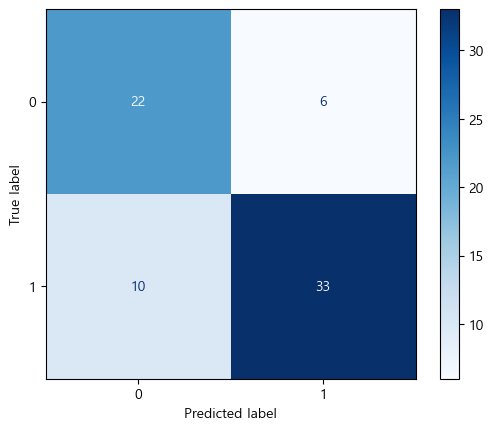

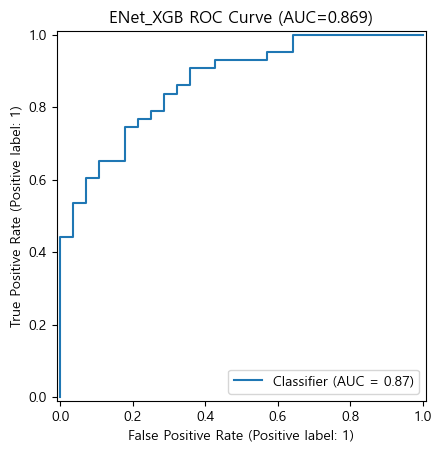


🔹 ENet_XGB SHAP 중요도 상위 변수


,feature,mean_abs_shap
6,student_interact,1.349631
4,prof_passion,1.173097
3,prof_access,1.102445
0,course_variety,1.021396
8,time_eff,0.906999
2,peer_event,0.791792
7,theory_cls,0.720760
5,prof_personal,0.702201
1,peer_advice,0.469476


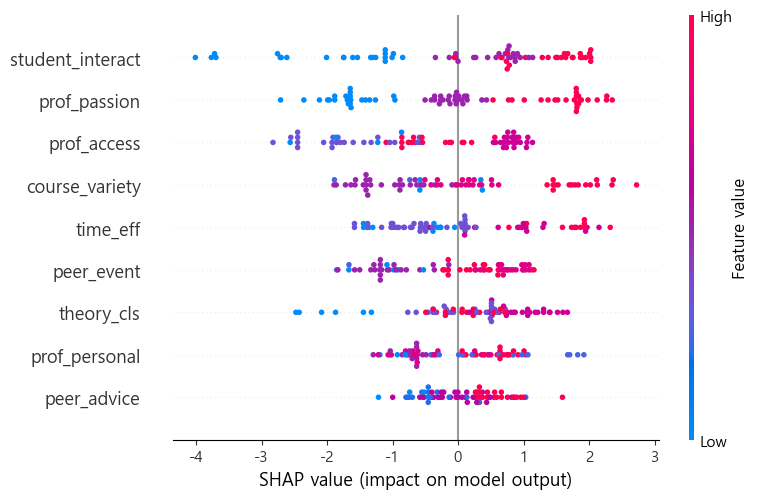


===== RFECV_RF =====
Confusion Matrix:


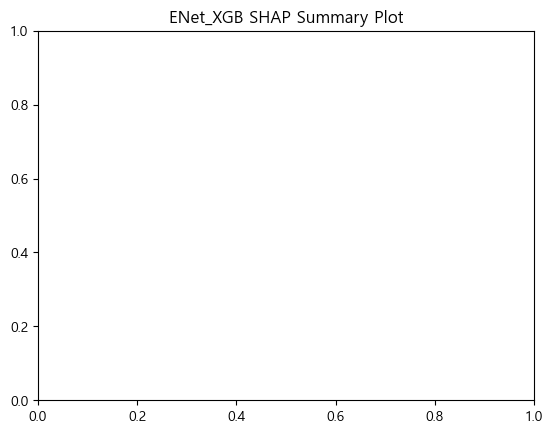

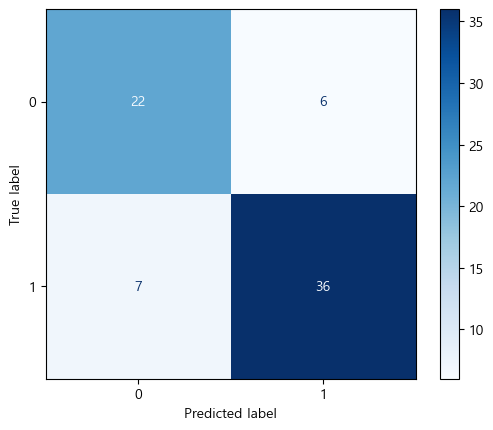

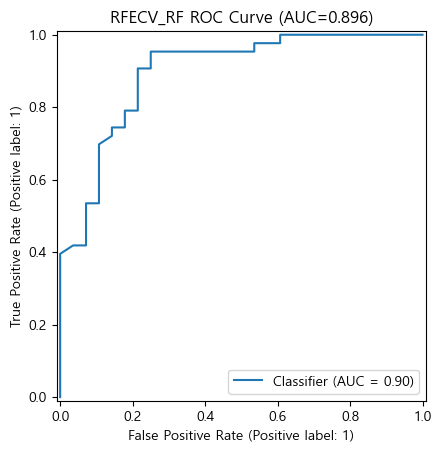


🔹 RFECV_RF SHAP 중요도 상위 변수


,feature,mean_abs_shap
25,prof_passion,0.061069
28,student_interact,0.054217
5,course_variety,0.042435
19,prof_access,0.040874
16,peer_event,0.034920
1,car_spt,0.025105
29,students_diligent,0.024463
32,theory_cls,0.017294
13,peer_advice,0.015980
26,prof_personal,0.015845


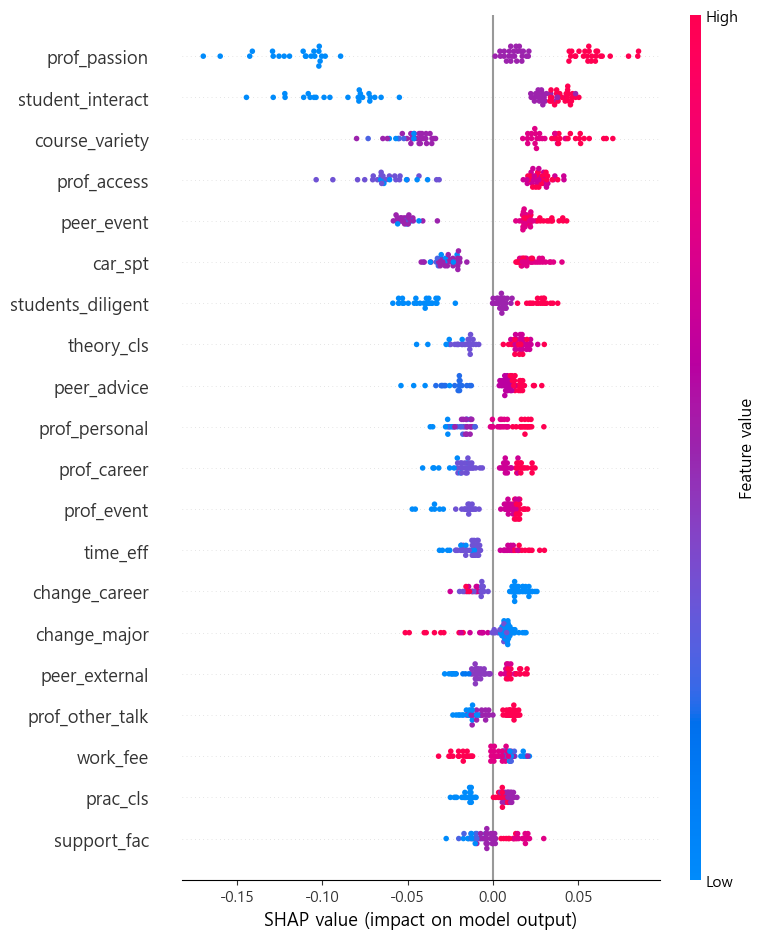

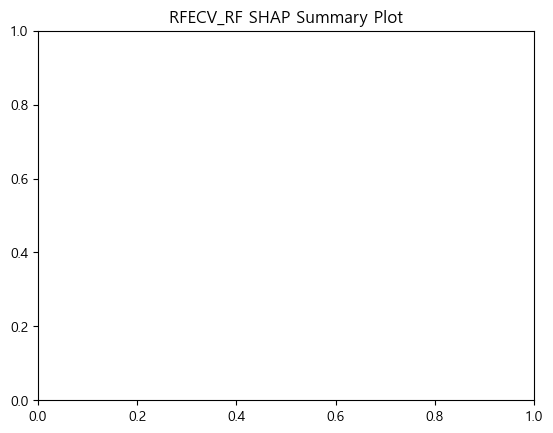

In [38]:
# ======================================
# ✅ 모델 집중 관찰: 혼동행렬, ROC, SHAP (수치 버전)
# ======================================

import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# -------------------------
# 설정
# -------------------------
RANDOM_STATE = 42

# -------------------------
# 집중 관찰할 변수 및 모델
# -------------------------
focus_models = {
    "ENet_XGB": {
        "model": XGBClassifier(
            n_estimators=300, random_state=RANDOM_STATE,
            eval_metric='logloss', use_label_encoder=False, n_jobs=-1
        ),
        "X": df[elasticnet_vars]
    },
    "RFECV_RF": {
        "model": RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "X": df[rfecv_rf_vars]
    }
}

# -------------------------
# 데이터 분할 함수
# -------------------------
def prepare_split(X_full, y):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_full, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


# -------------------------
# 모델별 평가
# -------------------------

for name, info in focus_models.items():
    print(f"\n===== {name} =====")
    X_full = info["X"]
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_split(X_full, y)

    model = info["model"]
    model.fit(X_train, y_train)

    # -------------------------
    # 혼동행렬
    # -------------------------
    print("Confusion Matrix:")
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
    plt.show()

    # -------------------------
    # ROC 커브 (AUC 소수점 3자리)
    # -------------------------
    try:
        y_score = model.predict_proba(X_test)[:, 1]
    except:
        y_score = model.decision_function(X_test)

    auc = roc_auc_score(y_test, y_score)  # AUC 계산
    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"{name} ROC Curve (AUC={auc:.3f})")  # 소수점 3자리
    plt.show()

    # -------------------------
    # SHAP 중요도 계산
    # -------------------------
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # 이진분류 → 양성 클래스(1) 선택
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)

    print(f"\n🔹 {name} SHAP 중요도 상위 변수")
    display(shap_importance.head(40))

    # -------------------------
    # SHAP Summary Plot
    # -------------------------
    shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)
    plt.title(f"{name} SHAP Summary Plot")


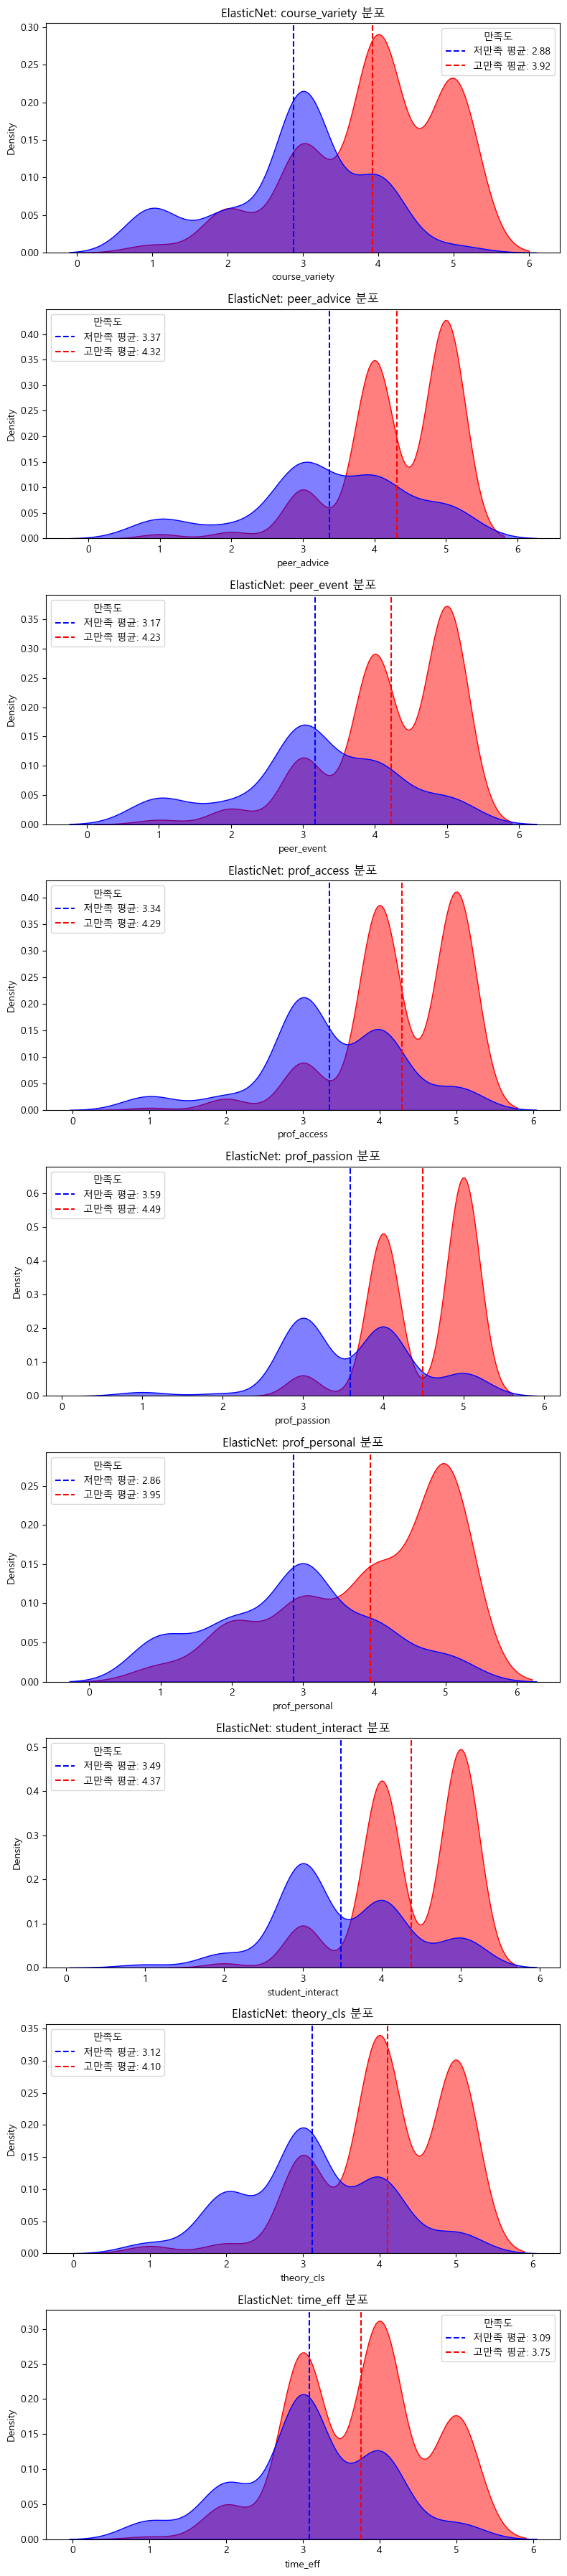

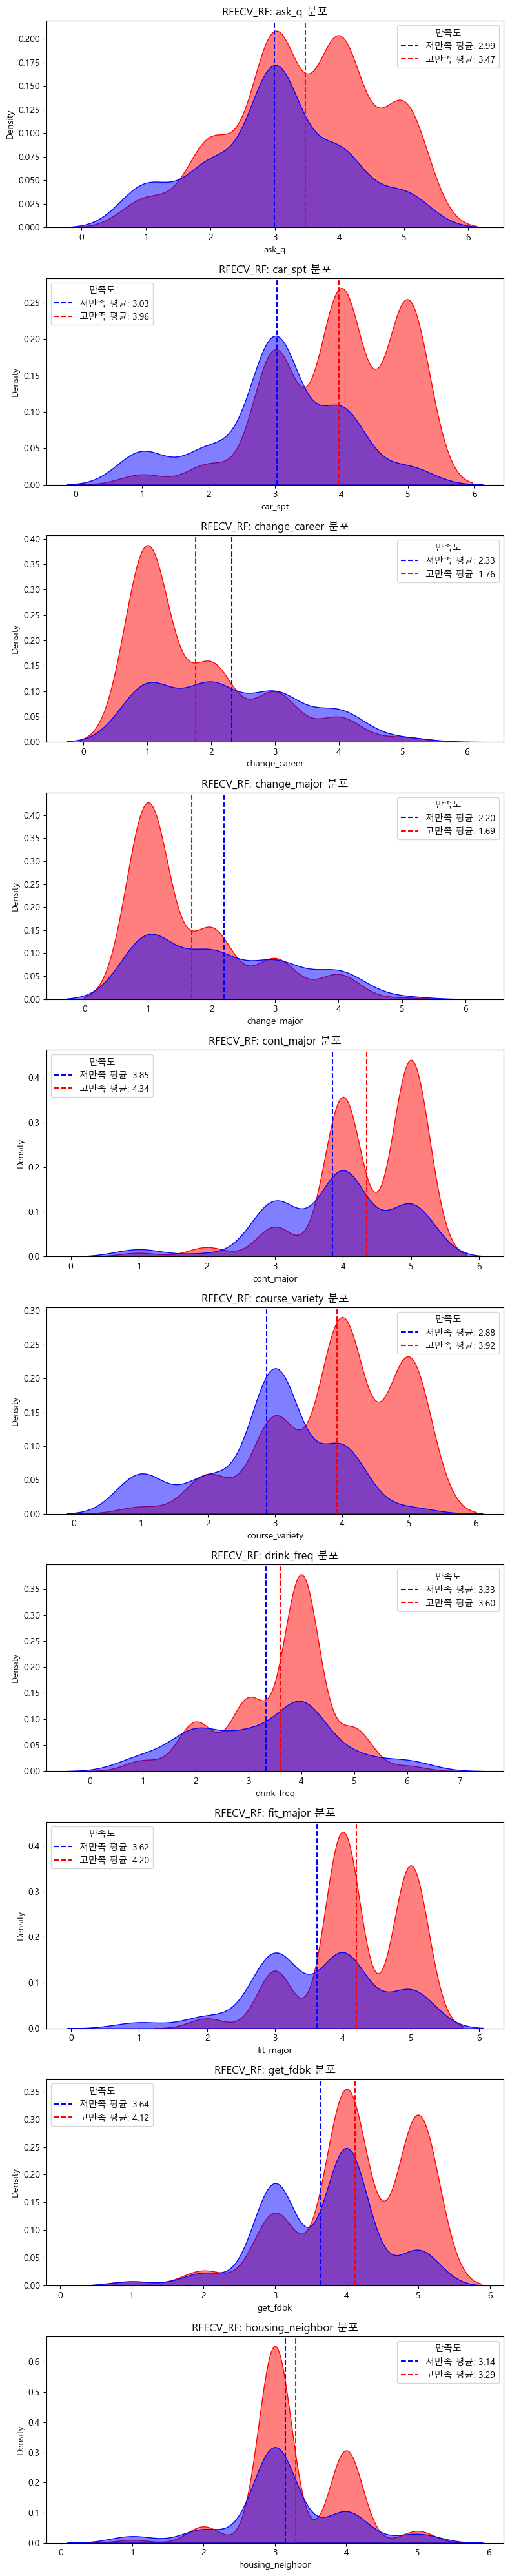

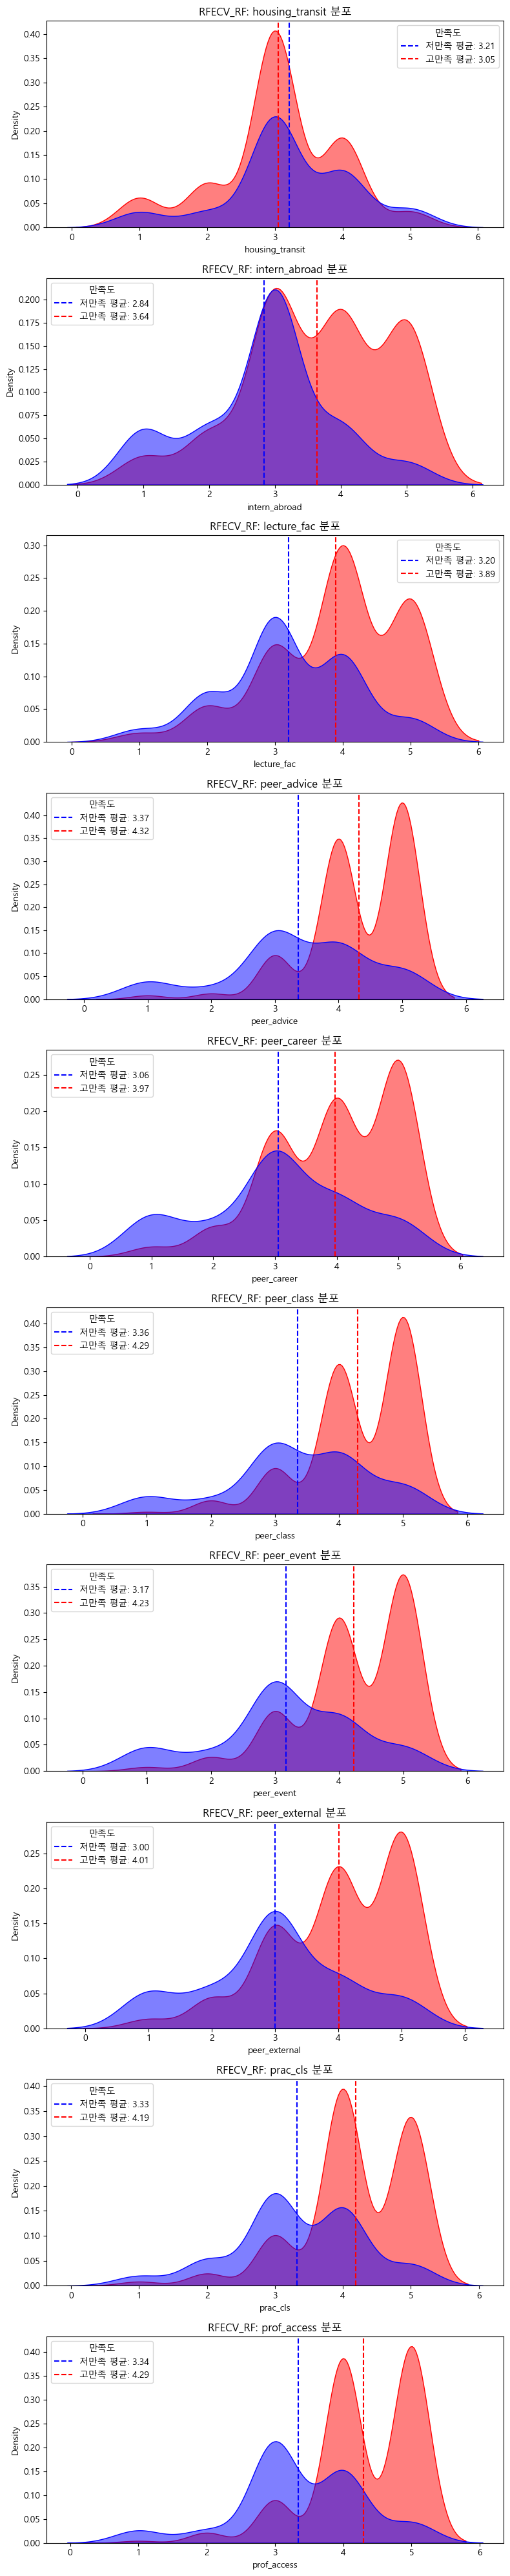

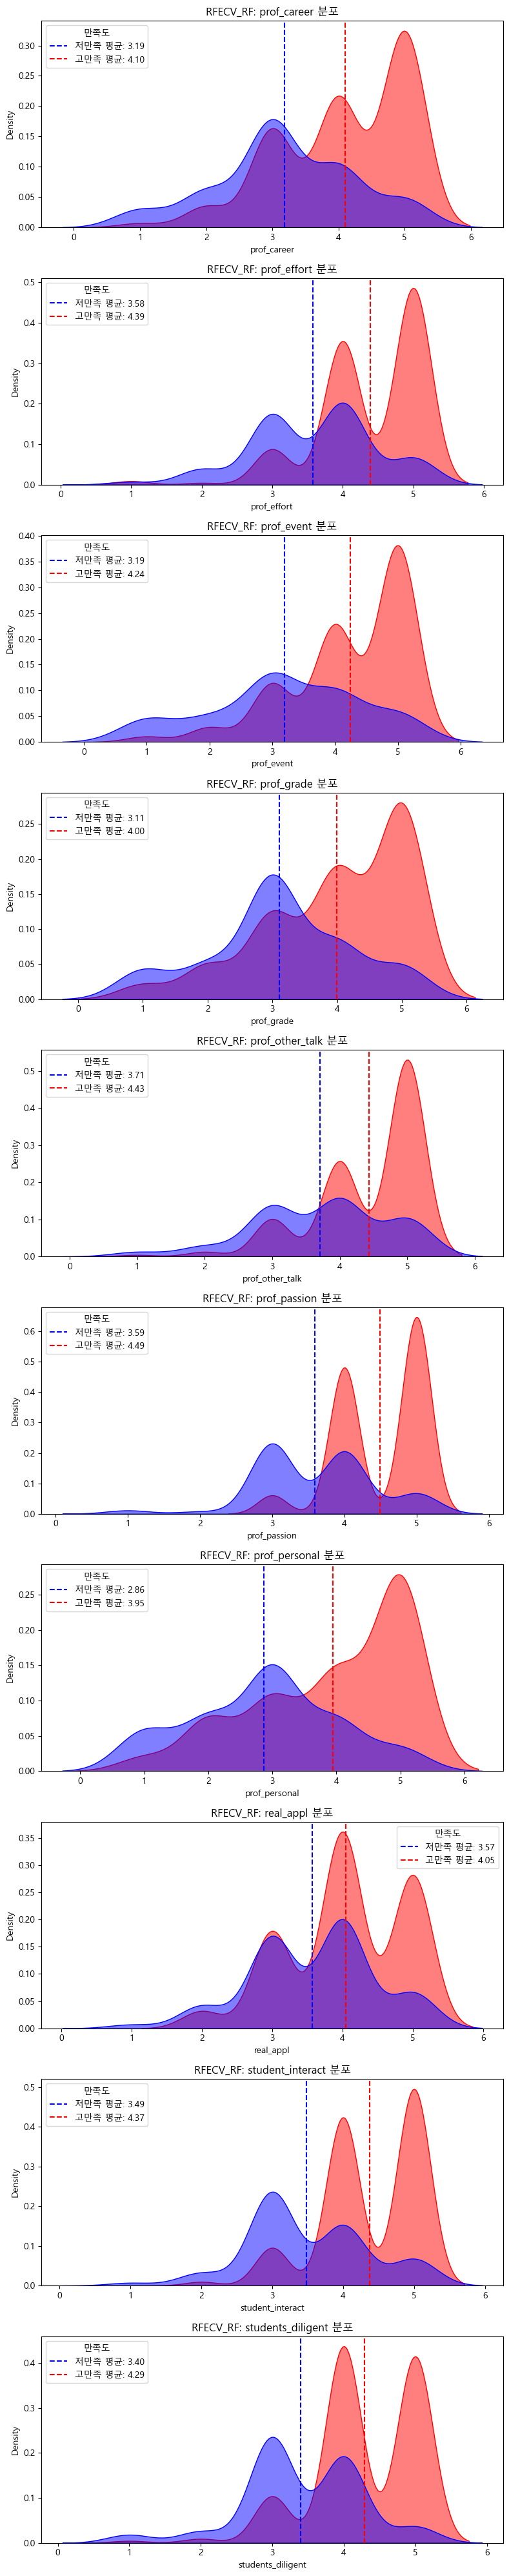

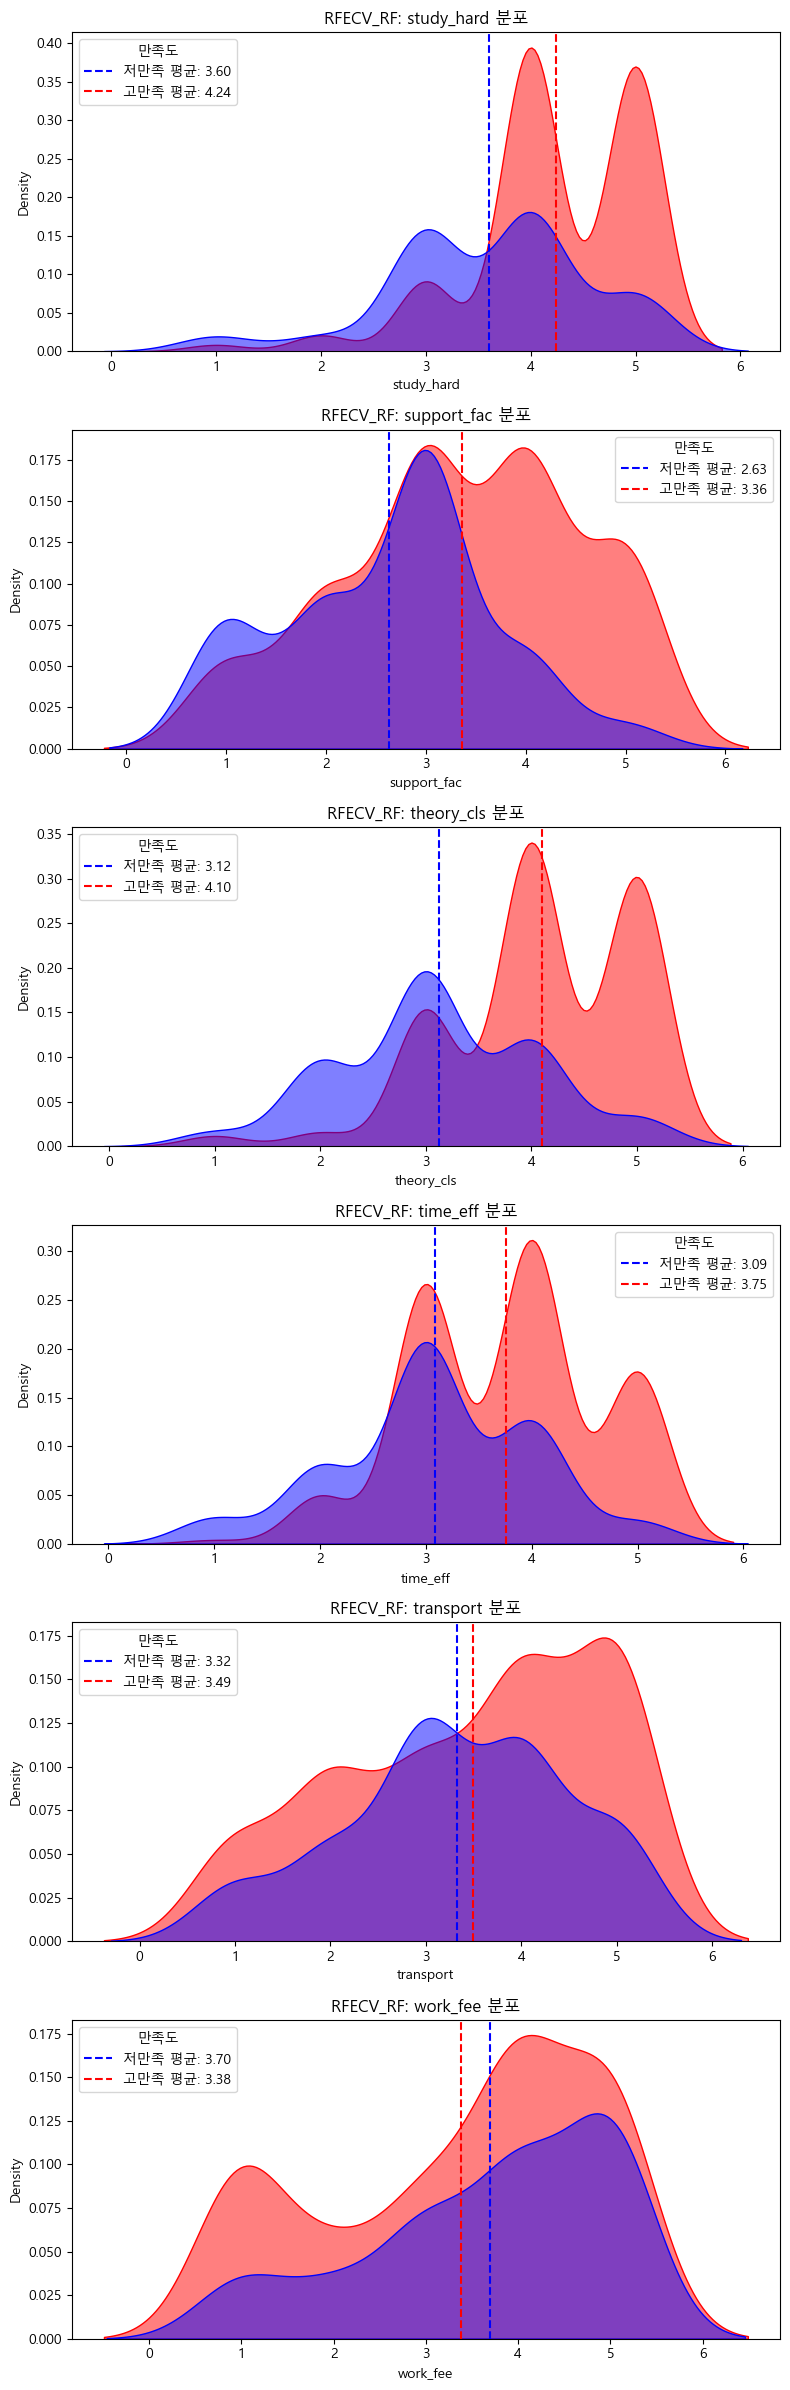

In [35]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

# 음수 기호 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False


import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 변수별 KDE: 고만족 vs 저만족
# -------------------------
def plot_kde_by_group(X_df, y_series, title_prefix=""):
    vars_ = X_df.columns
    n_vars = len(vars_)
    
    # subplot으로 한 화면에 표시 (최대 10개 변수는 한 화면)
    max_per_fig = 10
    for start in range(0, n_vars, max_per_fig):
        end = min(start + max_per_fig, n_vars)
        vars_subset = vars_[start:end]
        
        fig, axes = plt.subplots(len(vars_subset), 1, figsize=(8, 4*len(vars_subset)))
        if len(vars_subset) == 1:
            axes = [axes]  # 1개일 때 리스트로 변환
            
        for i, var in enumerate(vars_subset):
            sns.kdeplot(
                data=X_df,
                x=var,
                hue=y_series,
                fill=True,
                common_norm=True,   # 그룹 간 비교 쉽게
                palette={0: "blue", 1: "red"},
                alpha=0.5,
                ax=axes[i]
            )
            
            # 평균값 표시
            mean_0 = X_df[y_series==0][var].mean()
            mean_1 = X_df[y_series==1][var].mean()
            axes[i].axvline(mean_0, color='blue', linestyle='--', label=f'저만족 평균: {mean_0:.2f}')
            axes[i].axvline(mean_1, color='red', linestyle='--', label=f'고만족 평균: {mean_1:.2f}')
            
            axes[i].set_title(f"{title_prefix}{var} 분포")
            axes[i].set_xlabel(var)
            axes[i].set_ylabel("Density")
            axes[i].legend(title="만족도")
        
        plt.tight_layout()
        plt.show()


# -------------------------
# ElasticNet 변수 KDE
# -------------------------
plot_kde_by_group(focus_models["ENet_XGB"]["X"], y, title_prefix="ElasticNet: ")

# -------------------------
# RFECV_RF 변수 KDE
# -------------------------
plot_kde_by_group(focus_models["RFECV_RF"]["X"], y, title_prefix="RFECV_RF: ")
